In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from go_ml.train_utils import get_enzyme_df, enzyme_iterator, cls_seq_encode
import transformers
import matplotlib.pyplot as plt
tokenizer = transformers.AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')
from go_ml.go_utils import godag, go2parents_isa, get_ancestors

import json
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)

../go-basic.obo: fmt(1.2) rel(2024-04-24) 45,667 Terms


In [2]:
from Bio import SeqIO
with open("../eval_notebooks/interpro_cases/abc_transporter.fasta") as f:
    abc_prot = next(iter(SeqIO.parse(f, 'fasta')))
abc_domains = pd.read_csv("../eval_notebooks/interpro_cases/abc_transporter_dom.tsv", sep='\t')
abc_domains = abc_domains[~abc_domains['GO Terms'].isna()]

In [3]:
abc_terms = [gt.split(',') for gt in abc_domains['GO Terms']]
abc_term_ind = [[go_terms.index(t) for t in r] for r in abc_terms]
abc_domains['GO Ind'] = abc_term_ind
abc_domains

,Accession,Name,Source Database,Type,Integrated Into,Integrated Signatures,GO Terms,Protein Accession,Protein Length,Matches,GO Ind
3,IPR003439,"ABC transporter-like, ATP-binding domain",interpro,domain,NaN,"PS50893,PF00005","GO:0005524,GO:0016887",a0a001,591,344..573,"[3, 43]"
4,IPR003593,AAA+ ATPase domain,interpro,domain,NaN,SM00382,GO:0016887,a0a001,591,369..550,[43]
5,IPR011527,"ABC transporter type 1, transmembrane domain",interpro,domain,NaN,"PS50929,PF13748,PF06472,PF00664","GO:0005524,GO:0140359,GO:0055085,GO:0016020",a0a001,591,17..289,"[3, 879, 67, 4]"
6,IPR017871,"ABC transporter-like, conserved site",interpro,conserved_site,NaN,PS00211,"GO:0005524,GO:0016887",a0a001,591,478..492,"[3, 43]"
8,IPR036640,"ABC transporter type 1, transmembrane domain s...",interpro,homologous_superfamily,NaN,"G3DSA:1.20.1560.10,SSF90123","GO:0005524,GO:0016020",a0a001,591,1..301,"[3, 4]"


In [4]:
# import pickle
# with open('interpro_cases/abc_transporter_mut_scan.pkl', 'wb') as f:
#     pickle.dump(eval_dict, f)

import pickle
with open('../eval_notebooks/interpro_cases/abc_transporter_mut_scan.pkl', 'rb') as f:
    eval_dict = pickle.load(f)
eval_mat = np.stack([eval_dict[i] for i in range(1, len(eval_dict)+1)])

In [5]:
eval_mat.shape

(591, 20, 29185)

In [15]:
tokenizer = transformers.AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')
vocab = tokenizer.get_vocab()
token_ind_map = {v:k for k, v in vocab.items()}
aa_str = ''.join(token_ind_map[i] for i in range(4, 24))

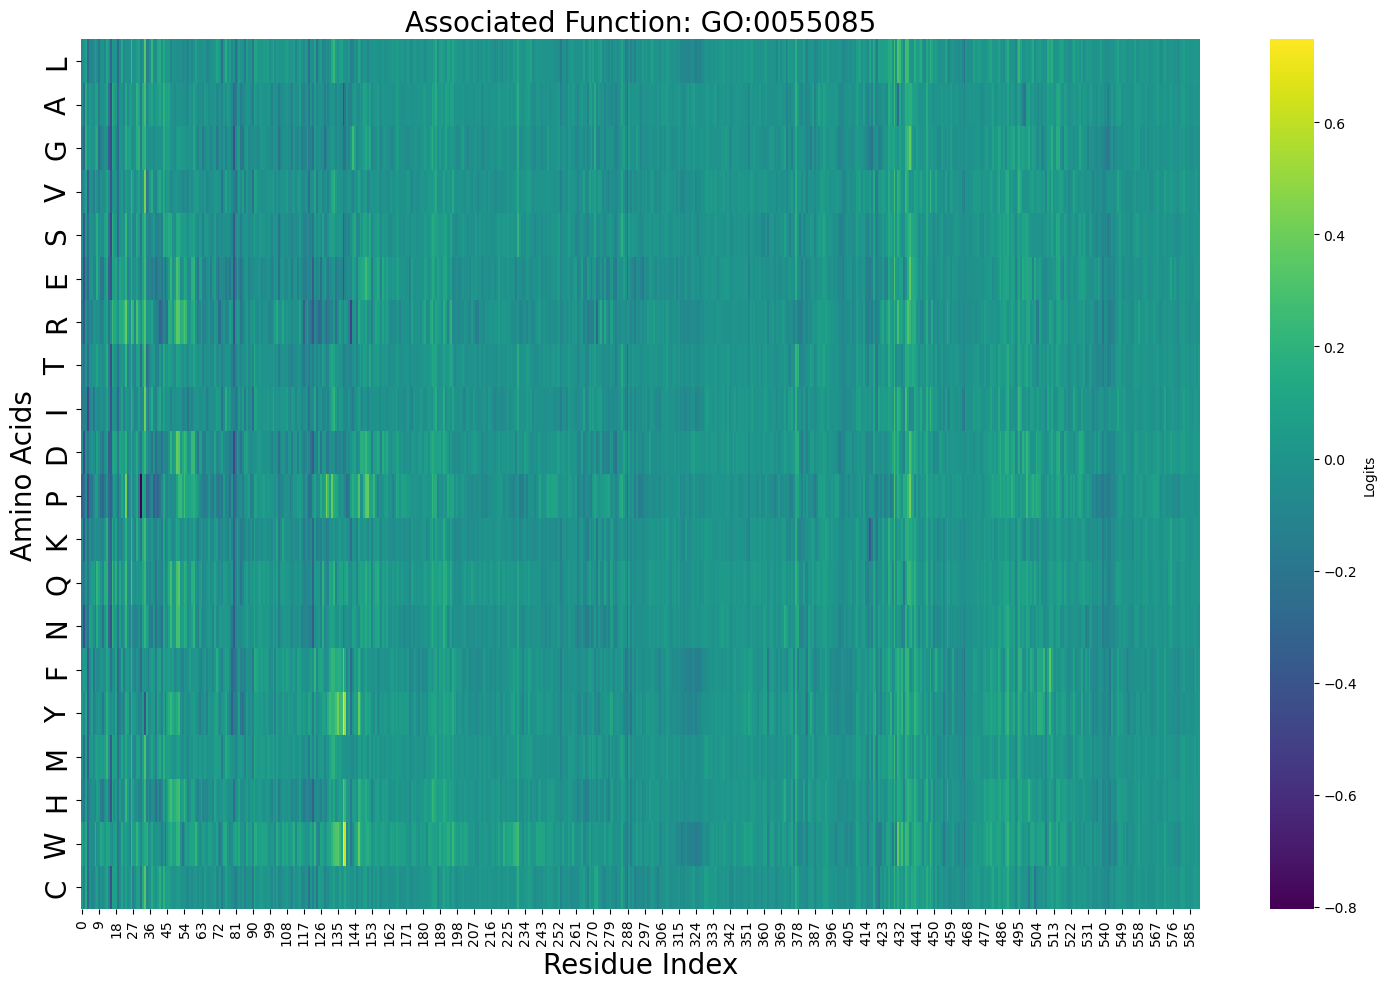

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
ax = sns.heatmap(eval_mat[:, :, 67].T - np.mean(eval_mat[:, :, 67]), cmap="viridis", cbar=True, cbar_kws={'label': 'Logits'})  
plt.title(f"Associated Function: {go_terms[67]}", fontsize=20)
plt.xlabel("Residue Index", fontsize=20)
plt.ylabel("Amino Acids", fontsize=20)
ax.set_yticklabels(aa_str, fontsize=20)
# ax.set_xticklabels(np.arange(0, eval_mat[:, :, 67].shape[0], 8))

plt.tight_layout()
plt.savefig("figures/abc_function.png")

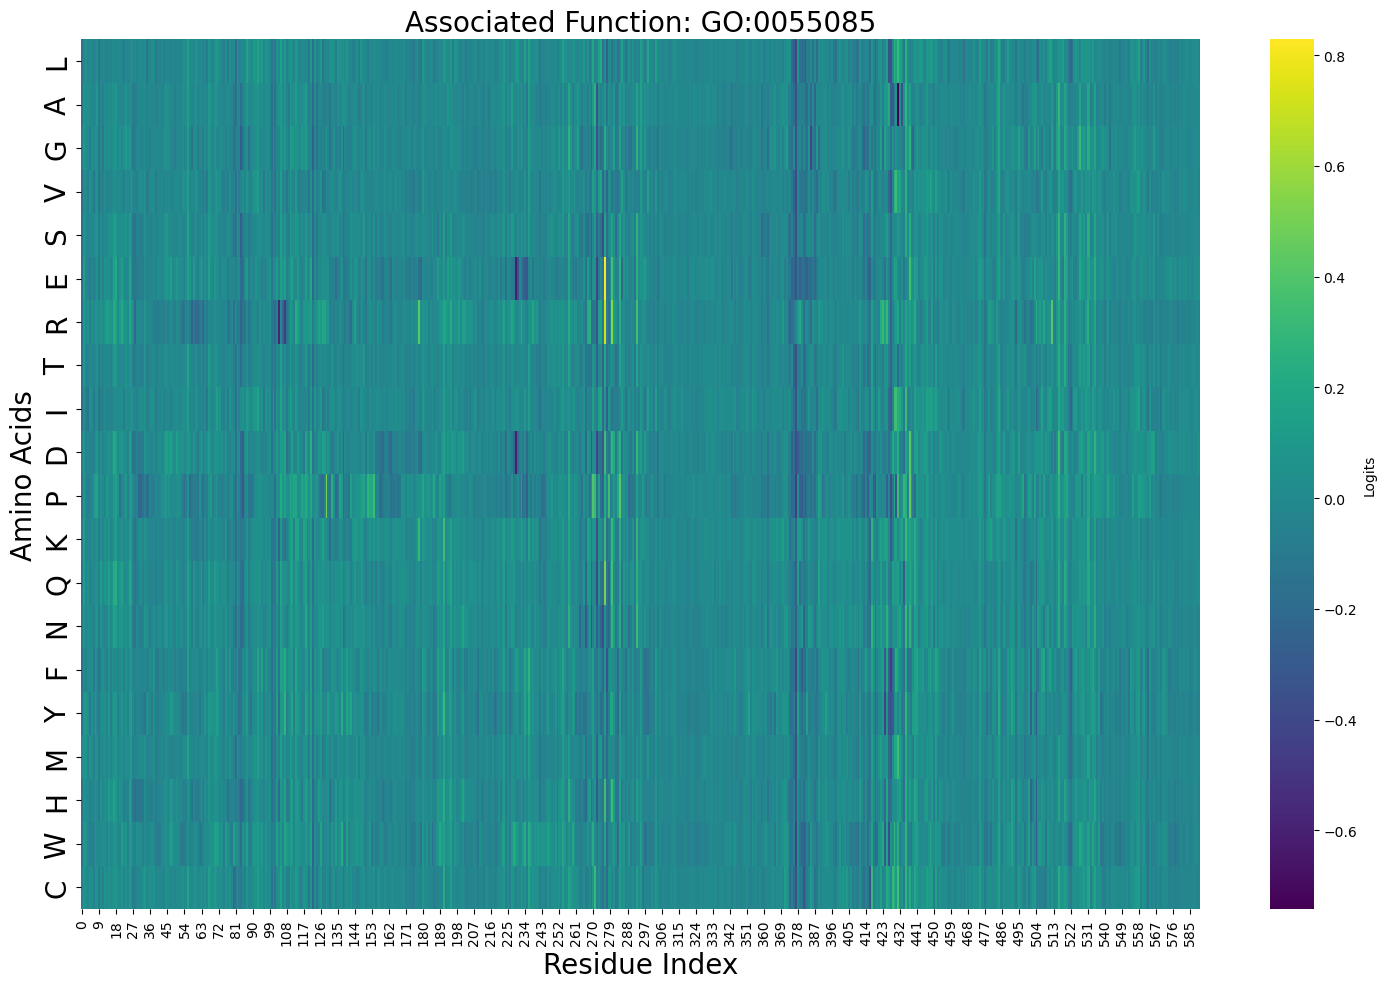

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
ax = sns.heatmap(eval_mat[:, :, 100].T - np.mean(eval_mat[:, :, 100]), cmap="viridis", cbar=True, cbar_kws={'label': 'Logits'})  
plt.title(f"Associated Function: {go_terms[67]}", fontsize=20)
plt.xlabel("Residue Index", fontsize=20)
plt.ylabel("Amino Acids", fontsize=20)
ax.set_yticklabels(aa_str, fontsize=20)
# ax.set_xticklabels(np.arange(0, eval_mat[:, :, 67].shape[0], 8))

plt.tight_layout()

plt.savefig("figures/abc_not_function.png")

In [12]:
abc_domains[['Name', 'GO Ind', 'Matches']]

,Name,GO Ind,Matches
3,"ABC transporter-like, ATP-binding domain","[3, 43]",344..573
4,AAA+ ATPase domain,[43],369..550
5,"ABC transporter type 1, transmembrane domain","[3, 879, 67, 4]",17..289
6,"ABC transporter-like, conserved site","[3, 43]",478..492
8,"ABC transporter type 1, transmembrane domain s...","[3, 4]",1..301


In [13]:
#Row normalize, col normalize, row entropy, base normalize, bert normalize
#P(Domain | in top x worst mutations pos/mutation delta)

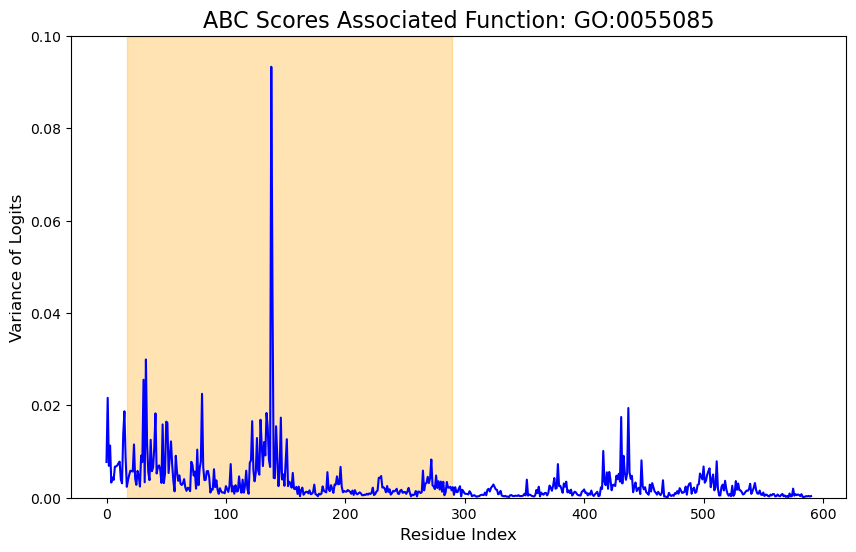

In [11]:
scores = np.var(eval_mat[:, :, 67], axis=1)

plt.figure(figsize=(10, 6))
sns.lineplot(x=range(len(scores)), y=scores, color="blue")
plt.title(f"ABC Scores Associated Function: {go_terms[67]}", fontsize=16)
plt.xlabel("Residue Index", fontsize=12)
plt.ylim((0, 0.1))
plt.ylabel("Variance of Logits", fontsize=12)

#highlight the indices from 17 to 289
plt.axvspan(17, 289, color='orange', alpha=0.3)

plt.savefig("figures/abc_function_scores.png")
plt.show()

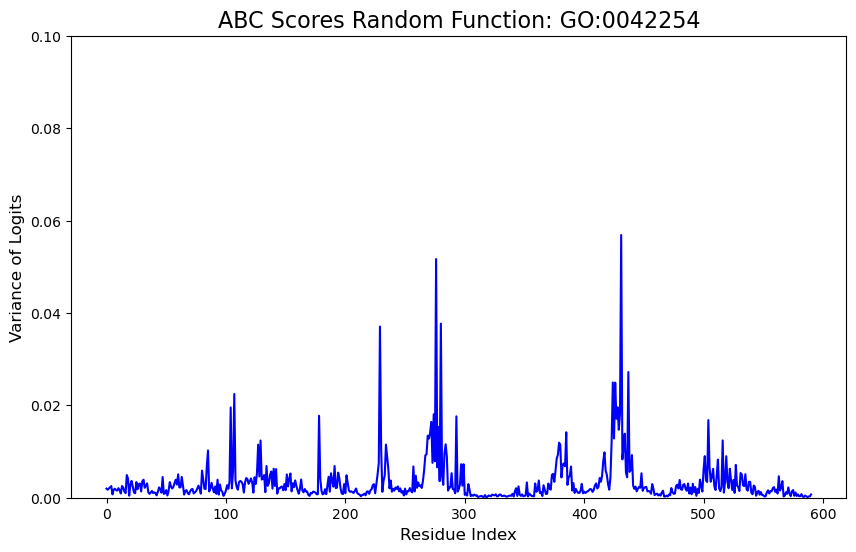

In [12]:

# import matplotlib.pyplot as plt
# go_ind = 879
# # plt.imshow(eval_mat[:, :, 879].T)

scores = np.var(eval_mat[:, :, 100], axis=1)

plt.figure(figsize=(10, 6))
sns.lineplot(x=range(len(scores)), y=scores, color="blue")
plt.title(f"ABC Scores Random Function: {go_terms[100]}", fontsize=16)
plt.ylim((0, 0.1))
plt.xlabel("Residue Index", fontsize=12)
plt.ylabel("Variance of Logits", fontsize=12)
plt.savefig("figures/abc_random_scores")
plt.show()

In [23]:
scores = np.var(eval_mat[:, :, 67], axis=1)
# scores plotted per resiude 
domain_mask = np.zeros(scores.shape)
domain_mask[17:289] = 1

perc_cutoff = len(scores)//20
top_score_ind = np.argsort(scores)[::-1][:perc_cutoff]
domain_mask[top_score_ind].sum() / perc_cutoff, domain_mask.mean()

(0.7931034482758621, 0.4602368866328257)

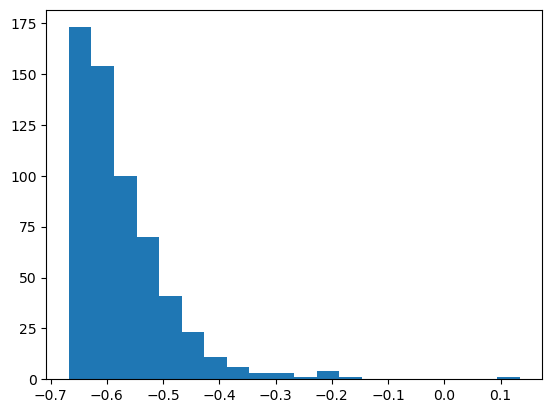

In [23]:
plt.hist(scores, bins=20)
plt.show()

In [ ]:
import numpy as np
def domain_viz(seq, domain_match):
    domain_mask = np.zeros((len(domain_match), len(seq)+1))
    for i, domain_range in enumerate(domain_match['matches']):
        si, ei = tuple([int(ind) for ind in domain_range.split('..')])
        domain_mask[i, si:ei] = 1